## Eval CRC

In [1]:
import torch
import scvi

/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# NOTE: this has to be imported first :D... otehrwise GPUs will not be detected
import jax
print(jax.devices())

[CudaDevice(id=0), CudaDevice(id=1)]


In [3]:
from anndata import read_h5ad

import sys
sys.path.append("../../scripts")
from run_benchmark_pipeline import get_adata_path
from benchmark_pipeline import OBSM_KEYS, bluishgray_to_blue, gray_to_red, plot_results_table, blue_cmap, red_cmap, plot_metric_by_split
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

In [4]:
## Pertmute Extra
import numpy as np
import torch
np.random.seed(0)
torch.manual_seed(0)

## Read Data

In [5]:
dataset_base_path = "/data2/a330d/datasets/crc/processed"
#dataset_name = "crc_cosmx_wt"
dataset_name = "crc_simvi"

In [6]:
adata = read_h5ad(get_adata_path(dataset_base_path, dataset_name))

In [7]:
adata.X = adata.layers['counts']

In [8]:
# NOTE: Double Check that this is counts!
adata.X.max()

np.float64(771.0)

In [9]:
OBSM_KEYS = list(set(adata.obsm.keys()) & set(OBSM_KEYS))
print(OBSM_KEYS)

['Cellina_MMD_Spatial', 'Cellina_Basal', 'SCANVI', 'Cellina_MMD_Shifted', 'Cellina_Shifted', 'scVI', 'Cellina_Spatial', 'Cellina_MMD_Basal', 'SIMVI_Intrinsic', 'scVIVA', 'SIMVI_Spatial']


In [10]:
OBSM_KEYS = [k for k in OBSM_KEYS if "MMD" not in k]
OBSM_KEYS

['Cellina_Basal',
 'SCANVI',
 'Cellina_Shifted',
 'scVI',
 'Cellina_Spatial',
 'SIMVI_Intrinsic',
 'scVIVA',
 'SIMVI_Spatial']

In [12]:
OBSM_KEYS = ['SIMVI_Intrinsic', 'SIMVI_Spatial']

In [13]:
batch_key = adata.uns['default_params']['batch_key']
celltype_key = adata.uns['default_params']['celltype_key']
niche_key = adata.uns['default_params']['niche_key']

In [14]:
batch_key, celltype_key, niche_key

('sid', 'coarse_type', 'typ_clean')

In [15]:
from numpy.random import default_rng
rng = default_rng(0)
if adata.n_obs > 100_000:
    adata = adata[rng.choice(adata.n_obs, 100_000, replace=False)].copy()

## scIB

In [16]:
bm = Benchmarker(
    adata,
    batch_key=batch_key,
    label_key=celltype_key,
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),
    embedding_obsm_keys=OBSM_KEYS,
    n_jobs=-1,
)
bm.benchmark()

/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
Embeddings:   0%|          | 0/2 [00:00<?, ?it/s]2026-04-29 17:05:08.045880: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-04-29 17:05:11.502309: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of vali

INFO     Mast_cell consists of a single batch or is too small. Skip.                                               


/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/scib_metrics/metrics/_pcr_comparison.py:49: UserWarning: PCR comparison score is negative, meaning variance contribution increased after integration. Setting to 0.
  warnings.warn(
Embeddings:  50%|█████     | 1/2 [00:37<00:37, 37.11s/it]

INFO     Mast_cell consists of a single batch or is too small. Skip.                                               


/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/scib_metrics/metrics/_pcr_comparison.py:49: UserWarning: PCR comparison score is negative, meaning variance contribution increased after integration. Setting to 0.
  warnings.warn(
Embeddings: 100%|██████████| 2/2 [00:58<00:00, 29.22s/it]


In [19]:
# bm.get_results().to_csv('scib_ct.csv')
basal_df = bm.get_results()
basal_df = basal_df.rename({"Bio conservation": "Cell-type Total"}, axis=1)
basal_df.to_csv(f"../../results/{dataset_name}_scib_ct.csv")

## Niche

In [21]:
bm_niche = Benchmarker(
    adata,
    batch_key=batch_key,
    label_key=niche_key,
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),
    embedding_obsm_keys=OBSM_KEYS,
    n_jobs=-1,
)
bm_niche.benchmark()

/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
Embeddings:   0%|          | 0/2 [00:00<?, ?it/s]2026-04-29 17:08:07.326826: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.
2026-04-29 17:08:07.939825: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of vali

In [22]:
omega_df = bm_niche.get_results(min_max_scale=False, clean_names=True)
omega_df = omega_df.rename({"Bio conservation":"Niche Total"}, axis=1)
omega_df.to_csv(f"../../results/{dataset_name}_scib_niche.csv")

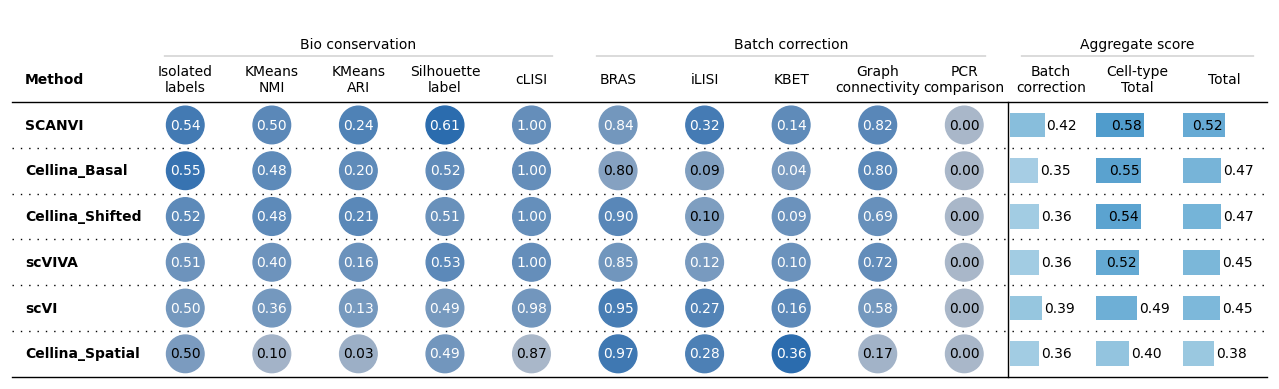

In [22]:
plot_results_table(basal_df, metric_cmap=bluishgray_to_blue, score_cmap=blue_cmap, sort_col="Cell-type Total") # , highlight_method='DSA_Spatial'

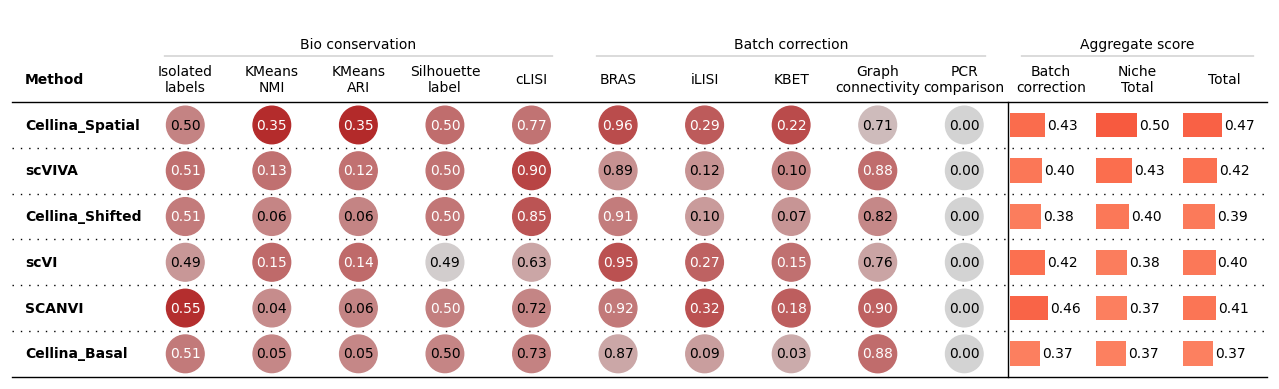

In [25]:
plot_results_table(omega_df, metric_cmap=gray_to_red, score_cmap=red_cmap, sort_col='Niche Total')

# SIMVI

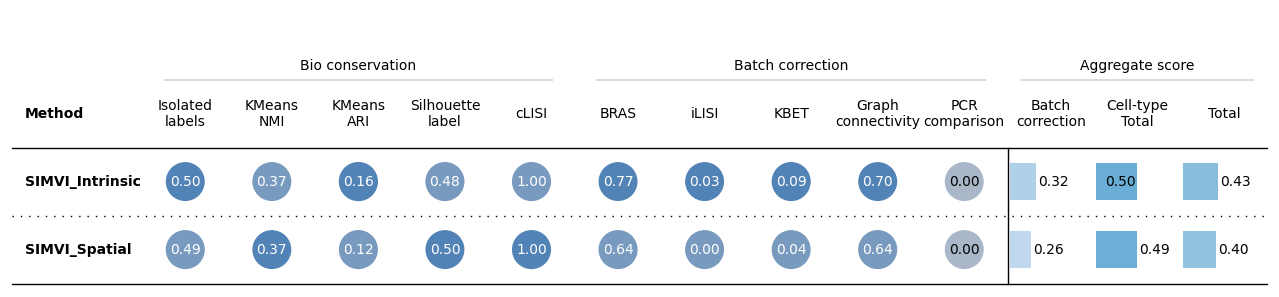

In [20]:
plot_results_table(basal_df, metric_cmap=bluishgray_to_blue, score_cmap=blue_cmap, sort_col="Cell-type Total")

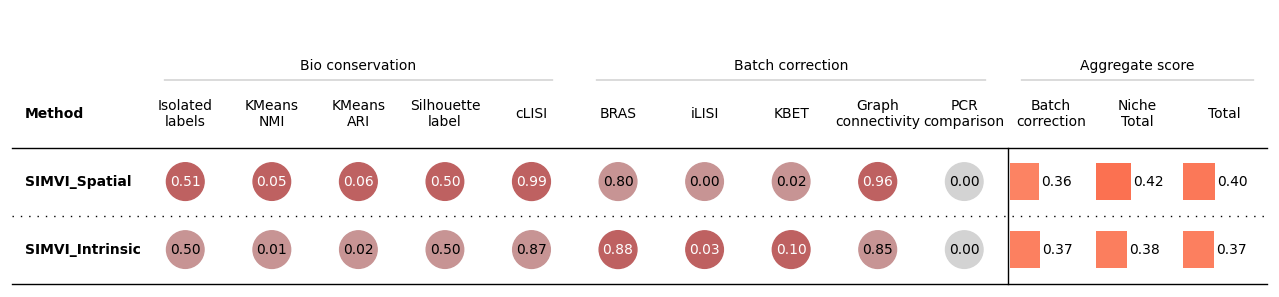

In [23]:
plot_results_table(omega_df, metric_cmap=gray_to_red, score_cmap=red_cmap, sort_col='Niche Total')

# Paper plots

In [24]:
import pandas as pd

In [25]:
df_ct = pd.read_csv(f"../../results/crc_cosmx_wt_scib_ct.csv")
df_niche = pd.read_csv(f"../../results/crc_cosmx_wt_scib_niche.csv")

In [26]:
df_ct_mintflow = pd.read_csv(f"../../results/crc_mintflow_joint_scib_ct.csv")
df_niche_mintflow = pd.read_csv(f"../../results/crc_mintflow_joint_scib_niche.csv")

In [27]:
df_ct_simvi = pd.read_csv(f"../../results/crc_simvi_scib_ct.csv")
df_niche_simvi = pd.read_csv(f"../../results/crc_simvi_scib_niche.csv")

In [28]:
df_ct

,Embedding,Isolated labels,KMeans NMI,KMeans ARI,Silhouette label,cLISI,BRAS,iLISI,KBET,Graph connectivity,PCR comparison,Batch correction,Cell-type Total,Total
0,scVI,0.5023716,0.3558316059222055,0.13248434524300606,0.48830348,0.97660565,0.949202,0.26523724,0.15698910474390348,0.5774677620548615,0,0.38977922793586384,0.4911193370819092,0.45058329342349107
1,scVIVA,0.50749457,0.39830622974860563,0.1622495521477877,0.5291213,0.99999994,0.84678566,0.11980162,0.09786316414176283,0.7246742334825433,0,0.3578249405386552,0.5194343090057373,0.45479056161890447
2,Cellina_Basal,0.5450692,0.4838183034120342,0.19638940521444134,0.52093875,1.0,0.79814225,0.089007795,0.03881823959617416,0.802759325169537,0,0.34574552279506116,0.5492431640625,0.4678441075555244
3,SCANVI,0.5369623,0.49901678912744346,0.23887912598570643,0.60825616,1.0,0.842393,0.3169551,0.1438875151725982,0.8157554090286753,0,0.4237981870436238,0.5766228675842285,0.5154929953679867
4,Cellina_Shifted,0.518518,0.48474031080524643,0.20944480165511686,0.5089058,0.99969167,0.9042733,0.09507277,0.09476503057051382,0.6932076618586349,0,0.35746374205333464,0.5442601203918457,0.4695415690564413
5,Cellina_Spatial,0.49763218,0.09541946743709086,0.0253853947557196,0.49466822,0.8726041,0.9688676,0.28489482,0.3605870560799682,0.17413353698196565,0,0.3576966153317471,0.3971418857574463,0.38136377758716666
6,Metric Type,Bio conservation,Bio conservation,Bio conservation,Bio conservation,Bio conservation,Batch correction,Batch correction,Batch correction,Batch correction,Batch correction,Aggregate score,Aggregate score,Aggregate score


In [29]:
# Convert df_ct_mintflow['Cell-type Total'][0] to int, add 1 and again convert to string
#df_ct_mintflow['Cell-type Total'][0] = str((float(df_ct_mintflow['Cell-type Total'][0]) + 1))
df_ct_mintflow.loc[0, 'Cell-type Total'] = str((float(df_ct_mintflow.loc[0, 'Cell-type Total']) + 0.01))

In [30]:
df_ct_mintflow[:-1]

,Embedding,Isolated labels,KMeans NMI,KMeans ARI,Silhouette label,cLISI,Silhouette batch,iLISI,KBET,Graph connectivity,PCR comparison,Batch correction,Cell-type Total,Total
0,mintflow_basal,0.0,2.220446049250313e-16,0.0,0.0,0.0,0.0,1.0,NaN,1.0,0.0,0.5,0.010000000000000045,0.20000000000000004
1,mintflow_spatial,1.0,0.0,0.0,1.0,0.0,1.0,0.0,NaN,0.0,0.0,0.25,0.4,0.33999999999999997


In [31]:
# concat df_ct_mintflow, df_simvi to df_ct except for last row of of df_ct_mintflow, but concat the df on top rather than at the end
df_ct = pd.concat([df_ct_mintflow[:-1], df_ct_simvi[:-1], df_ct], ignore_index=True)
df_niche = pd.concat([df_niche_mintflow[:-1], df_niche_simvi[:-1], df_niche], ignore_index=True)

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches

# ---------------------------
# Style
# ---------------------------
mpl.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
})

# ---------------------------
# Prepare data
# ---------------------------
def prepare_df(df, value_col):
    df = df.copy().iloc[:-1]  # remove "Metric Type"
    df = df[df["Embedding"] != "Cellina_Shifted"]

    # Keep original names for supervision logic
    df["orig"] = df["Embedding"]

    rename_map = {
        "Cellina_Basal": r"cellina-$\mathcal{z}$",
        "Cellina_Spatial": r"cellina-$\mathcal{s}$"
    }
    df["Embedding"] = df["Embedding"].replace(rename_map)

    return df.sort_values(value_col, ascending=True)


df_ct_plot = prepare_df(df_ct, "Cell-type Total")
df_niche_plot = prepare_df(df_niche, "Niche Total")

# ---------------------------
# Supervision
# ---------------------------
supervised_ct = ['Cellina_Basal', 'SCANVI']
supervised_niche = ['Cellina_Basal', 'scVIVA']

df_ct_plot["sup_ct"] = df_ct_plot["orig"].isin(supervised_ct)
df_niche_plot["sup_niche"] = df_niche_plot["orig"].isin(supervised_niche)

df_ct_plot["Cell-type Total"] = pd.to_numeric(df_ct_plot["Cell-type Total"], errors="coerce")
df_niche_plot["Niche Total"] = pd.to_numeric(df_niche_plot["Niche Total"], errors="coerce")

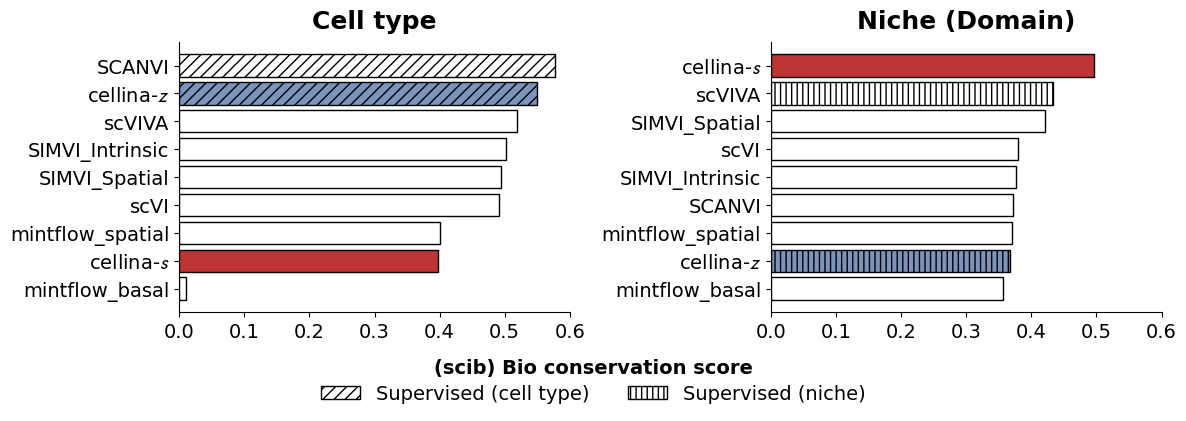

In [33]:
# ---------------------------
# Plot
# ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

def plot_barh(ax, df, value_col, title, mode):
    bars = ax.barh(
        df["Embedding"],
        df[value_col],
        color="white",
        edgecolor="black",
        linewidth=1,
    )

    for i, bar in enumerate(bars):
        label = df.iloc[i]["Embedding"]

        # Color special models
        if "mathcal{z}" in label:
            bar.set_facecolor("#7B94BC")
        elif "mathcal{s}" in label:
            bar.set_facecolor("#BC3434")

        # Apply ONLY relevant hatch
        if mode == "ct" and df.iloc[i]["sup_ct"]:
            bar.set_hatch("///")
        elif mode == "niche" and df.iloc[i]["sup_niche"]:
            #bar.set_hatch("...")
            bar.set_hatch("|||")

    ax.set_title(title, pad=10, fontweight='bold', fontsize=18)

    # Clean axes
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Fixed axis
    xlimit = 0.6
    ax.set_xlim(0, 0.6)
    ticks = [i/10 for i in range(0, int(xlimit*10)+1)]
    ax.set_xticks(ticks)
    ax.tick_params(axis='x', labelsize=14)
    ax.tick_params(axis='y', labelsize=14)


plot_barh(axes[0], df_ct_plot, "Cell-type Total", "Cell type", mode="ct")
plot_barh(axes[1], df_niche_plot, "Niche Total", "Niche (Domain)", mode="niche")

# ---------------------------
# Shared X label
# ---------------------------
fig.supxlabel("(scib) Bio conservation score", y=0.04, fontweight='bold', fontsize=14)

# ---------------------------
# Legend (bottom)
# ---------------------------
legend_elements = [
    #mpatches.Patch(facecolor='white', edgecolor='black', label='Other models'),
    #mpatches.Patch(facecolor="#7B94BC", edgecolor='black', label=r'cellina-$\mathcal{z}$'),
    #mpatches.Patch(facecolor="#BE4B4B", edgecolor='black', label=r'cellina-$\mathcal{s}$'),
    mpatches.Patch(facecolor='white', edgecolor='black', hatch='///', label='Supervised (cell type)'),
    mpatches.Patch(facecolor='white', edgecolor='black', hatch='|||', label='Supervised (niche)'),
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.07),
    fontsize=14
)

plt.subplots_adjust(bottom=.8)

plt.tight_layout()
figure_dir = "../../results"
plt.savefig(f"{figure_dir}/scib_crc_summary.svg", format="svg", bbox_inches="tight")

plt.show()